In [1]:
# ==========================================
# 1. Environment Setup & Imports
# ==========================================
import os
import sys
import glob
import math
import gc
import warnings
from pathlib import Path

# --- Project Root Discovery ---
# Robustly find the project root by looking for markers
current_path = Path.cwd()
project_root = None
markers = ['Experiment', 'RawDataProcessing', '.config']

cand_path = current_path
while cand_path != cand_path.parent:
    if any((cand_path / m).exists() for m in markers):
        project_root = cand_path
        break
    cand_path = cand_path.parent

if project_root is None:
    # Relative fallback from typical notebook location
    project_root = Path(os.path.abspath(os.path.join(os.getcwd(), '..', '..')))
    print("[WARN] Project root markers not found. Using relative fallback.")

# CRITICAL: Change CWD to project root so relative paths (like .config) work in imported modules
try:
    os.chdir(project_root)
    print(f"Changed Working Directory to: {os.getcwd()}")
except Exception as e:
    print(f"[WARN] Failed to change directory to {project_root}: {e}")

# Add to sys.path if not present
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

print(f"Project Root: {project_root}")

# --- Standard Library Imports ---
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- Project Imports ---
try:
    # These imports trigger code in Preprocess.py that expects CWD to be project root
    from RawDataProcessing.ParseLogFile import load_config
    from RawDataProcessing.GalaxyData import GalDataSet
    from Experiment.Network import MACNetRes_mbh, AccretionTransformer
    from Experiment.Preprocess import Exp_eg_folder_paths, Exp_dg_folder_paths
    print("[SUCCESS] Project modules imported successfully.")
except Exception as e:
    # Catching generic Exception because Preprocess.py might raise KeyError/FileNotFoundError
    print(f"[ERROR] Import failed: {e}")
    print("Fallback: Defining paths manually if import failed.")
    
    # Define fallback paths just in case to allow notebook to continue
    try:
        def load_config(p): return {}
        # Simple manual fallback for paths if Preprocess fails
        Exp_eg_folder_paths = []
        Exp_dg_folder_paths = []
    except: pass

# --- Congig Loading ---
# Load project-wide configs if available
configs = {}
config_path = project_root / '.config'
if config_path.exists():
    configs = load_config(str(config_path))
else:
    print("[INFO] No .config folder found, using defaults.")

# --- Metric Definitions (Fallback) ---
try:
    from sklearn.metrics import r2_score, explained_variance_score
except ImportError:
    print("[INFO] sklearn not found. Using fallback metric implementations.")
    def r2_score(y_true, y_pred):
        y_true, y_pred = np.asarray(y_true), np.asarray(y_pred)
        ss_res = np.sum((y_true - y_pred) ** 2)
        ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
        return 1.0 - (ss_res / ss_tot if ss_tot > 0 else np.nan)

    def explained_variance_score(y_true, y_pred):
        y_true, y_pred = np.asarray(y_true), np.asarray(y_pred)
        var_res = np.var(y_true - y_pred)
        var_true = np.var(y_true)
        return 1.0 - (var_res / var_true if var_true > 0 else np.nan)

Changed Working Directory to: d:\PersonFiles\Codes\Project\MACNet v1
Project Root: d:\PersonFiles\Codes\Project\MACNet v1
d:\PersonFiles\Codes\Project\MACNet v1
[SUCCESS] Project modules imported successfully.


In [2]:
# ==========================================
# 2. Configuration Parameters
# ==========================================

# Experiment Settings
EXP_PREFIX = 'Exp2_'        # Prefix for model/cache files (e.g. Exp1_, Exp2_)
MODEL_PATH_OVERRIDE = "D:\PersonFiles\Codes\Project\MACNet v1\Results\Exp_ViT_00120260116_145955"  # None = Auto-detect latest, or path str

# Paths
RESULTS_DIR = project_root / 'Results'
CACHE_DIR   = project_root / '.cache'
OUTPUT_ROOT = RESULTS_DIR   # Where to save analysis CSVs/Plots (usually next to model)

# Device Setup
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {DEVICE}")

# Plotting Settings
SAVE_FIGURES = True
FIGURE_FORMAT = 'png' # 'pdf', 'svg', 'png'
FIGURE_SUBDIR = 'figures'

# Constants
GALAXY_TYPES = {
    'Exp1_': 'elliptical',
    'Exp2_': 'disk', 
}
DEFAULT_TYPE = GALAXY_TYPES.get(EXP_PREFIX, 'disk')

Using device: cuda


<>:7: SyntaxWarning: invalid escape sequence '\P'
<>:7: SyntaxWarning: invalid escape sequence '\P'
C:\Users\Administrator\AppData\Local\Temp\ipykernel_34968\410325331.py:7: SyntaxWarning: invalid escape sequence '\P'
  MODEL_PATH_OVERRIDE = "D:\PersonFiles\Codes\Project\MACNet v1\Results\Exp_ViT_00120260116_145955"  # None = Auto-detect latest, or path str


In [3]:
# ==========================================
# 3. Helper Functions & Classes
# ==========================================

def find_latest_model(results_root: Path, exp_prefix: str) -> Path:
    """Finds the latest .pth model file matching the experiment prefix."""
    if not results_root.exists():
        return None
    # Check specific experiment folders first
    candidates = list(results_root.glob(f'{exp_prefix}*/*.pth'))
    if not candidates:
        # Fallback to recursive search
        candidates = list(results_root.glob('**/*.pth'))
    
    if not candidates:
        return None
    
    # Sort by modification time (newest first)
    candidates.sort(key=lambda p: p.stat().st_mtime, reverse=True)
    return candidates[0]

def ensure_tensor(arr, dtype=torch.float32):
    """Converts input to a contiguous tensor of specified dtype."""
    if arr is None: 
        return None
    if isinstance(arr, torch.Tensor):
        return arr.to(dtype=dtype).contiguous()
    return torch.as_tensor(arr, dtype=dtype).contiguous()

# --- Dataset Wrapper for Cached Data (.pt) ---
class CachedPTDataset:
    def __init__(self, pt_path: Path):
        self.path = pt_path
        if not pt_path.exists():
            raise FileNotFoundError(f"Cached dataset not found: {pt_path}")
            
        loaded = torch.load(pt_path, map_location='cpu', weights_only=False)
        items = list(loaded)
        
        # Unpack based on length (handling diff preprocessing versions)
        self.coord = None
        self.y_bondi = None
        self.groups = None
        self.type = 'cached'

        # Standard Preprocess.py sequence: (x, coord, y, mbh, y_bondi, groups, n_groups)
        if len(items) >= 5:
             # Heuristic: Check if item[1] looks like coordinates (usually 2D/3D tensor)
            if isinstance(items[1], (torch.Tensor, np.ndarray)) and items[1].ndim >= 2:
                # ViT Format
                self.x, self.coord, self.y, self.mbh, self.y_bondi, self.groups = items[:6]
                self.kind = 'vit'
            else:
                # MACNet Format (no coord)
                self.x, self.y, self.mbh, self.y_bondi, self.groups = items[:5]
                self.kind = 'macnet'
        else:
            # Minimal Fallback
            self.x, self.y, self.mbh = items[:3]
            self.kind = 'macnet'

        # Standardization
        self.x = ensure_tensor(self.x)
        self.coord = ensure_tensor(self.coord)
        self.y = ensure_tensor(self.y).view(-1, 1)
        self.mbh = ensure_tensor(self.mbh).view(-1, 1)
        self.y_bondi = ensure_tensor(self.y_bondi).view(-1, 1) if self.y_bondi is not None else None
        
        if self.groups is not None:
             # Handle numpy string arrays which fail torch conversion
            if isinstance(self.groups, np.ndarray) and self.groups.dtype.kind in ('S', 'U'):
                 # Convert to unique integer IDs
                _, indices = np.unique(self.groups, return_inverse=True)
                self.groups = torch.as_tensor(indices, dtype=torch.long)
            else:
                self.groups = torch.as_tensor(self.groups)

    def __len__(self):
        return len(self.y)

# --- Dataset Wrapper for Raw HDF5 Data ---
class HDF5Dataset:
    def __init__(self, hdf5_conf, resolution='coarse'):
        """
        hdf5_conf: tuple (folder_path, id_array) 
                   OR just folder_path string
        """
        if isinstance(hdf5_conf, (list, tuple)):
            self.folder_path = hdf5_conf[0]
        else:
            self.folder_path = hdf5_conf
            
        # Infer type from folder name
        self.type = os.path.basename(os.path.dirname(self.folder_path)).lower()
        
        # Load via Project's Data Pipeline
        loaded = GalDataSet().load_data((self.folder_path, 0)) # 0 is dummy group id
        loaded.drop_invalid().filter(-5)
        
        self.x, _, _ = loaded.standardize()
        self.coord = loaded.coordinate
        self.y = loaded.y
        self.mbh = loaded.mbh
        self.y_bondi = loaded.y_baseline if hasattr(loaded, 'y_baseline') else None
        
        # Additional fields for time evolution
        # Use raw_data directly if property access fails
        self.time = loaded.time
        self.mdot_edd = np.array(loaded._raw_data['mdot_edd']) if 'mdot_edd' in loaded._raw_data else None
        
        # Determine kind automatically
        self.kind = 'vit' if self.coord is not None else 'macnet'

    def __len__(self):
        return len(self.y)

In [4]:
# ==========================================
# 4. Load Models & Cached Data
# ==========================================
import torch.nn as nn
from Experiment.Network import FourierPositionalEncoding2D, FiLMConditioner, MLP, TransformerBlock as NewTransformerBlock

# --- Definition of Legacy Classes for Old Checkpoints ---
# (Required because Network.py was updated with architecture changes)

class LegacyTransformerBlock(nn.Module):
    def __init__(self, d_model: int, n_heads: int, d_ff: int, p_drop: float = 0.1):
        super().__init__()
        self.norm1 = nn.LayerNorm(d_model)
        self.attn = nn.MultiheadAttention(d_model, n_heads, dropout=p_drop, batch_first=True)
        self.drop1 = nn.Dropout(p_drop)
        self.norm2 = nn.LayerNorm(d_model)
        self.mlp = MLP(d_model, d_ff, p_drop)

    def forward(self, x, gamma=None, beta=None):
        # Old FiLM logic: x = gamma * x + beta (without 1+)
        if gamma is not None and beta is not None:
            x = gamma * x + beta 

        h = self.norm1(x)
        h, _ = self.attn(h, h, h, need_weights=False)
        x = x + self.drop1(h)

        if gamma is not None and beta is not None:
            x = gamma * x + beta

        h = self.norm2(x)
        h = self.mlp(h)
        x = x + h
        return x

class LegacyAccretionTransformer(nn.Module):
    def __init__(self, c_in, d_model=256, n_layers=8, n_heads=8, d_ff=1024, pos_num_bands=32, pos_max_freq=64.0, p_drop=0.1):
        super().__init__()
        self.posenc = FourierPositionalEncoding2D(num_bands=pos_num_bands, max_frequency=pos_max_freq, include_input=True)
        d_pos = self.posenc.out_dim
        
        # Legacy Structure: Project to d_model // 2, then Concat with Dropout(feat)
        self.content_proj = nn.Conv2d(c_in, d_model // 2, kernel_size=1)
        self.pos_proj = nn.Conv2d(d_pos, d_model // 2, kernel_size=1)
        self.drop = nn.Dropout(p_drop)
        
        self.cls_token = nn.Parameter(torch.zeros(1, 1, d_model))
        nn.init.trunc_normal_(self.cls_token, std=0.02)
        
        # Use Legacy Block
        self.blocks = nn.ModuleList([
            LegacyTransformerBlock(d_model, n_heads, d_ff, p_drop) for _ in range(n_layers)
        ])
        
        self.film = FiLMConditioner(n_layers, d_model)
        self.head = nn.Sequential(
            nn.LayerNorm(d_model),
            nn.Linear(d_model, d_model // 2),
            nn.GELU(),
            nn.Linear(d_model // 2, 1),
        )

    def forward(self, x, r, theta, bh_mass):
        B, C, H, W = x.shape
        pos = self.posenc(r, theta, normalize=True)
        
        # Legacy Fusion
        feat = self.content_proj(x) + self.pos_proj(pos)
        feat = torch.cat([feat, self.drop(feat)], dim=1) # (B, D, H, W)
        
        tokens = feat.flatten(2).transpose(1, 2)
        cls = self.cls_token.expand(B, -1, -1)
        tokens = torch.cat([cls, tokens], dim=1)
        
        gammas, betas = self.film(bh_mass)
        x_tok = tokens
        for i, blk in enumerate(self.blocks):
            # Legacy FiLM expansion
            gamma = gammas[i].expand(B, x_tok.size(1), -1)
            beta = betas[i].expand(B, x_tok.size(1), -1)
            x_tok = blk(x_tok, gamma=gamma, beta=beta)
            
        return self.head(x_tok[:, 0, :]).squeeze(-1)

# --- End Legacy Classes ---

# 1. Load Cached Splits
splits = ['train', 'val', 'test']
datasets = {}
print("Loading cached datasets...")
for split in splits:
    pt_path = CACHE_DIR / f"{EXP_PREFIX}{split}.pt"
    if pt_path.exists():
        try:
            ds = CachedPTDataset(pt_path)
            datasets[split] = ds
            print(f"  - [{split.upper()}] Loaded {len(ds)} samples ({ds.kind})")
        except Exception as e:
            print(f"  - [{split.upper()}] Failed to load: {e}")
            datasets[split] = None
    else:
        print(f"  - [{split.upper()}] Not found at {pt_path}")
        datasets[split] = None

# 2. Locate Model
if MODEL_PATH_OVERRIDE:
    model_path = Path(MODEL_PATH_OVERRIDE)
    # Handle directory input by finding the best .pth inside
    if model_path.is_dir():
        candidates = list(model_path.glob('*.pth'))
        if candidates:
            # Prefer 'best' if multiple
            best = [p for p in candidates if 'best' in p.name]
            model_path = best[0] if best else candidates[0]
            print(f"  [INFO] Auto-detected file in override dir: {model_path.name}")
        else:
            raise RuntimeError(f"No .pth model found in directory: {model_path}")
else:
    model_path = find_latest_model(RESULTS_DIR, EXP_PREFIX)

if not model_path or not model_path.exists():
    raise RuntimeError(f"No model found for prefix '{EXP_PREFIX}' in {RESULTS_DIR}")

print(f"Target Model: {model_path}")

# 3. Initialize Model Structure
# Determine model type from state_dict keys
state = torch.load(model_path, map_location=DEVICE)
raw_state = state.get('model', state.get('state_dict', state))
keys = list(raw_state.keys())

def infer_model_type(keys):
    if any(k.startswith('content_proj') or k.startswith('blocks') for k in keys):
        return 'vit'
    return 'macnet'

model_type = infer_model_type(keys)
print(f"Detected Architecture: {model_type.upper()}")

# Reference dataset for input channels
ref_ds = next((ds for ds in datasets.values() if ds is not None), None)
if ref_ds is None:
    raise RuntimeError("Cannot initialize model without at least one loaded dataset to check dimensions.")
in_ch = int(ref_ds.x.shape[1])

# Initialize Architecture
if model_type == 'vit':
    # HACK: Infer ViT Config from weights if possible
    # 1. d_model
    d_model = 256
    if 'cls_token' in raw_state:
        d_model = raw_state['cls_token'].shape[-1]
    
    # Check for Legacy vs New Architecture using content_proj weight shape
    # Legacy: weight shape [d_model/2, c_in, ...]
    # New:    weight shape [d_model, c_in, ...]
    is_legacy = False
    if 'content_proj.weight' in raw_state:
        cp_shape = raw_state['content_proj.weight'].shape
        if cp_shape[0] == d_model // 2:
            is_legacy = True
            print(f"  [INFO] Detected LEGACY architecture (content_proj output = {cp_shape[0]} vs d_model={d_model})")
    
    # 2. n_layers
    block_ids = [int(k.split('.')[1]) for k in keys if k.startswith('blocks.')]
    n_layers = max(block_ids) + 1 if block_ids else 8

    # 3. d_ff (Feed Forward Dimension)
    # Try to find any MLP layer weight to determine d_ff
    d_ff = 4 * d_model # default
    for k in keys:
        if 'mlp.fc1.weight' in k:
            d_ff = raw_state[k].shape[0]
            break
            
    print(f"  Inferred ViT Config: d_model={d_model}, n_layers={n_layers}, d_ff={d_ff}")

    if is_legacy:
        model = LegacyAccretionTransformer(
            c_in=in_ch, d_model=d_model, n_layers=n_layers, 
            n_heads=max(1, d_model // 32), d_ff=d_ff
        ).to(DEVICE)
    else:
        model = AccretionTransformer(
            c_in=in_ch, d_model=d_model, n_layers=n_layers, 
            n_heads=max(1, d_model // 32), d_ff=d_ff
        ).to(DEVICE)
else:
    model = MACNetRes_mbh(in_channels=in_ch).to(DEVICE)

# Load Weights
model.load_state_dict(raw_state, strict=False)
model.eval()
print("Model loaded successfully.")

# Setup Column Names
COL_PRED = 'y_pred'
COL_ERR  = 'error'
MODEL_LABEL = 'MACNet' if model_type == 'macnet' else 'MAC ViT'

Loading cached datasets...
  - [TRAIN] Loaded 3426 samples (vit)
  - [VAL] Loaded 923 samples (vit)
  - [TEST] Loaded 952 samples (vit)
  [INFO] Auto-detected file in override dir: Exp_ViT_001best_model.pth
Target Model: D:\PersonFiles\Codes\Project\MACNet v1\Results\Exp_ViT_00120260116_145955\Exp_ViT_001best_model.pth
Detected Architecture: VIT
  Inferred ViT Config: d_model=256, n_layers=2, d_ff=1024
Model loaded successfully.


In [5]:
# ==========================================
# 5. Prediction Logic
# ==========================================

@torch.no_grad()
def predict_dataset(ds, model, device, batch_size=32):
    """
    Unified prediction for both CachedPTDataset and HDF5Dataset.
    Returns a DataFrame with columns: [y_true, y_pred, y_bondi, type, error, bondi_error, time, mdot_edd]
    """
    if ds is None: return None
    
    # 1. Prepare Tensors
    x_all = ensure_tensor(ds.x)
    mbh_all = ensure_tensor(ds.mbh)
    coord_all = ensure_tensor(ds.coord) if getattr(ds, 'coord', None) is not None else None
    
    total = len(ds)
    preds = []
    
    # Adaptive Batch Size
    bs = batch_size
    if model_type == 'vit': bs = 8  # ViT uses more VRAM
    
    # 2. Inference Loop
    for start in range(0, total, bs):
        end = min(start + bs, total)
        x_batch = x_all[start:end].to(device)
        mbh_batch = mbh_all[start:end].to(device).view(-1)
        
        if model_type == 'vit':
            if coord_all is None:
                raise ValueError("ViT model requires coordinates, but dataset has none.")
            c_batch = coord_all[start:end].to(device)
            # Assuming coord format matches AccretionTransformer inputs (r, theta)
            y_out = model(x_batch, c_batch[:, 0:1], c_batch[:, 1:2], mbh_batch)
        else:
            y_out = model(x_batch, mbh_batch)
            
        preds.append(y_out.cpu().view(-1))
        
    y_pred = torch.cat(preds).numpy()
    y_true = ensure_tensor(ds.y).view(-1).numpy()
    
    # 3. Construct DataFrame
    df = pd.DataFrame({
        'y_true': y_true,
        COL_PRED: y_pred
    })
    
    # Add Metadata
    if ds.y_bondi is not None:
        df['y_bondi'] = ensure_tensor(ds.y_bondi).view(-1).numpy()
        # Filter invalid Bondi
        df.loc[np.isclose(df['y_bondi'], -100), 'y_bondi'] = np.nan
        df['bondi_error'] = df['y_bondi'] - df['y_true']

    if hasattr(ds, 'time') and ds.time is not None:
        df['time'] = np.array(ds.time)
    
    if hasattr(ds, 'mdot_edd') and ds.mdot_edd is not None:
        df['mdot_edd'] = np.array(ds.mdot_edd)
        
    df[COL_ERR] = df[COL_PRED] - df['y_true']
    
    if hasattr(ds, 'type'):
        df['type'] = ds.type
    elif hasattr(ds, 'groups') and ds.groups is not None:
        # Try to map groups to types if map available (simplified here)
        df['type'] = 'unknown_group' 
    else:
        df['type'] = 'test_set'
        
    # Cleanup memory
    del x_all, mbh_all, coord_all
    if torch.cuda.is_available(): torch.cuda.empty_cache()
    gc.collect()
    
    return df

print("Prediction function ready.")

Prediction function ready.


In [6]:
# ==========================================
# 6. Execution: Run Predictions
# ==========================================

all_results = {}

# A. Run on Cached Test Set
if datasets['test']:
    print(f"Predicting on Cached Test Set ({len(datasets['test'])} samples)...")
    res_test = predict_dataset(datasets['test'], model, DEVICE)
    res_test['type'] = 'Cached Test'
    all_results['test_cached'] = res_test

# B. Run on Raw Datasets (as defined in Preprocess)
# Configure paths dynamically based on Exp_prefix or fallbacks
raw_paths = []
try:
    if EXP_PREFIX == 'Exp1_':
        raw_paths = Exp_eg_folder_paths
    else:
        raw_paths = Exp_dg_folder_paths
except NameError:
    # Manual Fallback if imports failed
    print("[INFO] Using manual path fallback.")
    res = 'coarse' # or 'fine'
    folder = 'disk_galaxy_fiducial' if EXP_PREFIX == 'Exp2_' else 'elliptical_galaxy_fiducial'
    p = project_root / 'Data' / folder / res
    if p.exists():
        raw_paths = [(str(p), np.array([0,0]))]

print(f"\nPredicting on {len(raw_paths)} Raw Datasets...")
dfs_raw = []
for p_conf in raw_paths:
    try:
        # p_conf is (path, id)
        ds_raw = HDF5Dataset(p_conf)
        print(f"  > Processing {ds_raw.type} ({len(ds_raw)} samples)...")
        
        df = predict_dataset(ds_raw, model, DEVICE)
        dfs_raw.append(df)
    except Exception as e:
        print(f"  [Error] Failed to process {p_conf}: {e}")

if dfs_raw:
    all_results['raw_all'] = pd.concat(dfs_raw, ignore_index=True)

# C. Save Results
output_dir = model_path.parent
print(f"\nSaving results to {output_dir}...")
for name, df in all_results.items():
    s_path = output_dir / f"{name}_predictions.csv"
    df.to_csv(s_path, index=False)
    print(f"  Saved: {s_path.name}")

Predicting on Cached Test Set (952 samples)...

Predicting on 6 Raw Datasets...
  > Processing disk_galaxy_fiducial (875 samples)...
  > Processing disk_galaxy_supplement (896 samples)...
  > Processing disk_galaxy_fiducial_4 (489 samples)...
  > Processing disk_galaxy_fiducial_7 (527 samples)...
  > Processing disk_galaxy_fiducial_10 (953 samples)...
  > Processing disk_galaxy_low (942 samples)...

Saving results to D:\PersonFiles\Codes\Project\MACNet v1\Results\Exp_ViT_00120260116_145955...
  Saved: test_cached_predictions.csv
  Saved: raw_all_predictions.csv


In [7]:
# ==========================================
# 7. Visualization Utilities
# ==========================================

# Setup output dir for figures
fig_dir = output_dir / FIGURE_SUBDIR
fig_dir.mkdir(exist_ok=True, parents=True)

COLORS = ["#4B8D69", "#55658B", "#c1c16f", "#685587", "#B353CB", "#D78E5A", "#F06969"]

def save_plot(name):
    if SAVE_FIGURES:
        clean_name = name.replace(' ', '_').lower()
        path = fig_dir / f"{clean_name}.{FIGURE_FORMAT}"
        plt.savefig(path, dpi=150, bbox_inches='tight')
        # print(f"Saved figure: {path.name}")

def plot_scatter(df, title, limit_range=True):
    """Correlation Scatter Plot with 1-dex region."""
    plt.figure(figsize=(6, 6), dpi=120)
    
    # Data bounds
    vmin = min(df['y_true'].min(), df[COL_PRED].min()) - 0.5
    vmax = max(df['y_true'].max(), df[COL_PRED].max()) + 0.5
    
    # Reference Lines
    plt.plot([vmin, vmax], [vmin, vmax], 'r--', lw=1.5, label='Ideal', zorder=5)
    plt.plot([vmin, vmax], [vmin-1, vmax-1], 'k--', lw=0.8, alpha=0.5, label=r'$\pm$1 dex')
    plt.plot([vmin, vmax], [vmin+1, vmax+1], 'k--', lw=0.8, alpha=0.5)

    # Predictions
    # If multiple types, color by type
    groups = df['type'].unique()
    for i, g in enumerate(groups):
        sub = df[df['type'] == g]
        plt.scatter(sub['y_true'], sub[COL_PRED], s=8, alpha=0.4, 
                    color=COLORS[i % len(COLORS)], label=f"{g} (Pred)", edgecolors='none')
    
    # Bondi (optional)
    if 'y_bondi' in df.columns:
        plt.scatter(df['y_true'], df['y_bondi'], s=15, marker='x', alpha=0.2, 
                    color='gray', label='Bondi', zorder=1)

    plt.title(title)
    plt.xlabel(r'True $\log_{10}(\dot{M}/\dot{M}_{Edd})$')
    plt.ylabel(r'Predicted $\log_{10}(\dot{M}/\dot{M}_{Edd})$')
    if limit_range:
        plt.xlim(vmin, vmax)
        plt.ylim(vmin, vmax)
    plt.legend(loc='upper left')
    plt.grid(True, linestyle=':', alpha=0.3)
    save_plot(f"scatter_{title}")
    plt.show()

def plot_error_dist(df, title):
    """Violin plot of errors."""
    plt.figure(figsize=(8, 5), dpi=120)
    
    # Melt for seaborn
    plot_data = []
    # Model Errors
    tmp = df[[COL_ERR, 'type']].copy()
    tmp['Method'] = MODEL_LABEL
    tmp.rename(columns={COL_ERR: 'Error'}, inplace=True)
    plot_data.append(tmp)
    
    # Bondi Errors
    if 'bondi_error' in df.columns:
        tmp2 = df[['bondi_error', 'type']].dropna().copy()
        tmp2['Method'] = 'Bondi'
        tmp2.rename(columns={'bondi_error': 'Error'}, inplace=True)
        plot_data.append(tmp2)
        
    final_df = pd.concat(plot_data)
    
    sns.violinplot(data=final_df, x='type', y='Error', hue='Method', 
                   split=True, inner='quartile', palette='muted')
    
    plt.axhline(0, color='r', linestyle='--', alpha=0.5)
    plt.axhline(1, color='gray', linestyle=':', alpha=0.5)
    plt.axhline(-1, color='gray', linestyle=':', alpha=0.5)
    
    plt.title(f"Error Distribution: {title}")
    plt.ylabel(r"Error (dex)")
    plt.xticks(rotation=15)
    save_plot(f"violin_{title}")
    plt.show()

def plot_kde_contour(df, title):
    """KDE Contour of distributions."""
    plt.figure(figsize=(6, 6), dpi=120)
    sns.kdeplot(x=df['y_true'], y=df[COL_PRED], hue=df['type'], 
                fill=True, alpha=0.3, levels=5, palette=COLORS[:len(df['type'].unique())])
    
    vmin, vmax = df['y_true'].min(), df['y_true'].max()
    plt.plot([vmin, vmax], [vmin, vmax], 'r--', lw=1)
    
    plt.title(f"Density Contour: {title}")
    plt.xlabel("True")
    plt.ylabel("Predicted")
    save_plot(f"kde_{title}")
    plt.show()

def plot_metrics_summary(m_df):
    """Bar charts for overall metrics comparison."""
    df_plot = m_df.copy()
    
    fig, axes = plt.subplots(1, 3, figsize=(18, 5), dpi=120)
    
    # 1. Error Metrics (RMSE & MAE)
    x = np.arange(len(df_plot))
    width = 0.35
    axes[0].bar(x - width/2, df_plot['RMSE'], width, label='RMSE', color=COLORS[0])
    axes[0].bar(x + width/2, df_plot['MAE'], width, label='MAE', color=COLORS[1])
    axes[0].set_title('RMSE & MAE (Lower is better)')
    axes[0].set_xticks(x)
    axes[0].set_xticklabels(df_plot['Dataset'], rotation=45, ha='right')
    axes[0].legend()
    
    # 2. R2 Score
    axes[1].bar(df_plot['Dataset'], df_plot['R2'], color=COLORS[3])
    axes[1].set_title('R2 Score (Higher is better)')
    axes[1].axhline(0, color='black', linewidth=0.8)
    axes[1].set_xticklabels(df_plot['Dataset'], rotation=45, ha='right')
    
    # 3. Outlier Fraction
    axes[2].bar(df_plot['Dataset'], df_plot['OutlierFrac (>1dex)'], color=COLORS[6])
    axes[2].set_title('Outlier Fraction (>1 dex) %')
    axes[2].set_ylabel('%')
    axes[2].set_xticklabels(df_plot['Dataset'], rotation=45, ha='right')
    
    plt.tight_layout()
    save_plot("metrics_summary")
    plt.show()

def plot_mass_evolution(df, title):
    """
    Plots the cumulative black hole mass increment over time.
    Requires 'time', 'mdot_edd', 'y_true', and COL_PRED columns.
    """
    if 'time' not in df.columns or 'mdot_edd' not in df.columns:
        print(f"Skipping Mass Evolution for {title}: Missing 'time' or 'mdot_edd' info.")
        return

    # Sort by time
    df_plot = df.sort_values('time').copy()
    
    # Calculate dt (Gyr)
    times = df_plot['time'].values
    dt = np.diff(times, prepend=times[0])
    
    # Calculate Absolute Accretion Rates (simulation units: 2.5e7 M_sun/Gyr)
    # y = log10(mdot / mdot_edd) => mdot = 10^y * mdot_edd
    mdot_true = (10 ** df_plot['y_true']) * df_plot['mdot_edd']
    mdot_pred = (10 ** df_plot[COL_PRED]) * df_plot['mdot_edd']
    
    # Cumulative sum (Mass Increment)
    UNIT_MASS = 2.5e7 # Conversion factor to M_sun
    mass_inc_true = np.cumsum(mdot_true * dt) * UNIT_MASS
    mass_inc_pred = np.cumsum(mdot_pred * dt) * UNIT_MASS
    
    plt.figure(figsize=(10, 5), dpi=120)
    plt.plot(times, mass_inc_true, 'k-', lw=2, label='True (MACER)', alpha=0.8)
    plt.plot(times, mass_inc_pred, 'r--', lw=2, label=f'Predicted ({MODEL_LABEL})', alpha=0.8)
    
    # Bondi mass increment (optional)
    if 'y_bondi' in df.columns:
        mdot_bondi = (10 ** df_plot['y_bondi']) * df_plot['mdot_edd']
        mass_inc_bondi = np.cumsum(mdot_bondi.fillna(0) * dt) * UNIT_MASS
        plt.plot(times, mass_inc_bondi, 'g:', lw=1.5, label='Bondi', alpha=0.6)

    plt.yscale('log')
    plt.title(f"Black Hole Mass Growth: {title}")
    plt.xlabel("Time (Gyr)")
    plt.ylabel(r"$\Delta M_{BH}$ [$M_{\odot}$]")
    plt.legend()
    plt.grid(True, linestyle=':', alpha=0.5)
    
    save_plot(f"mass_evo_{title}")
    plt.show()

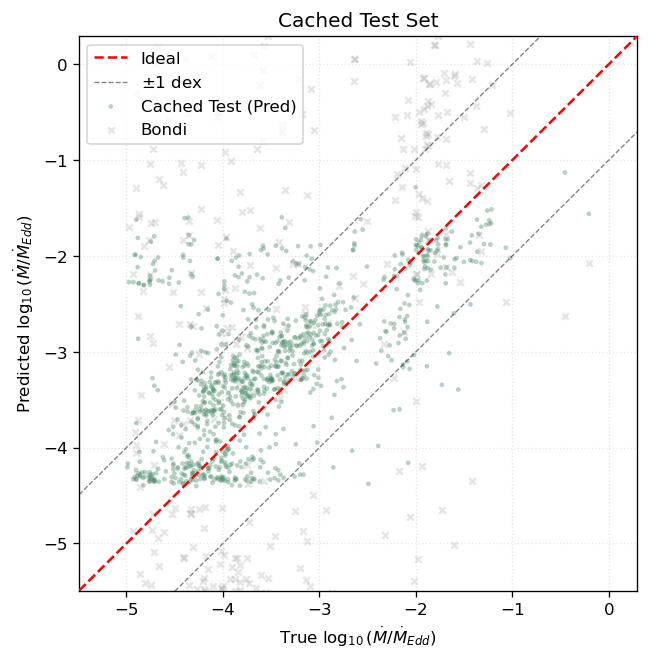

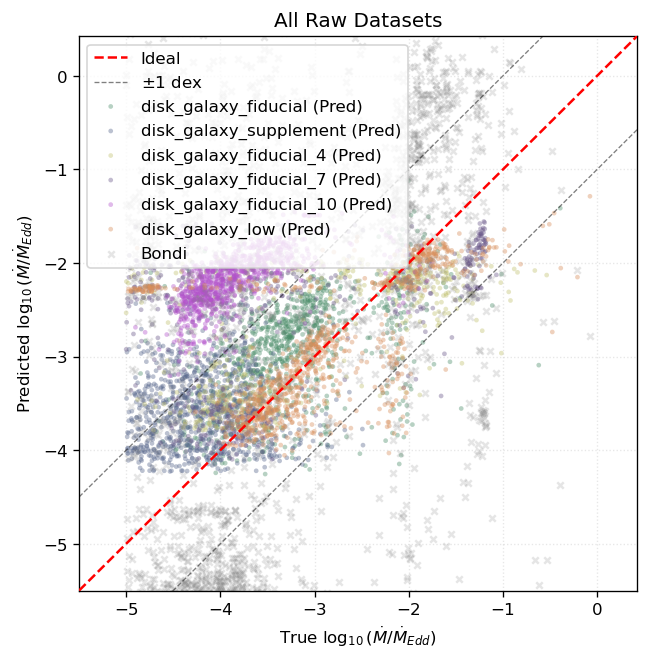

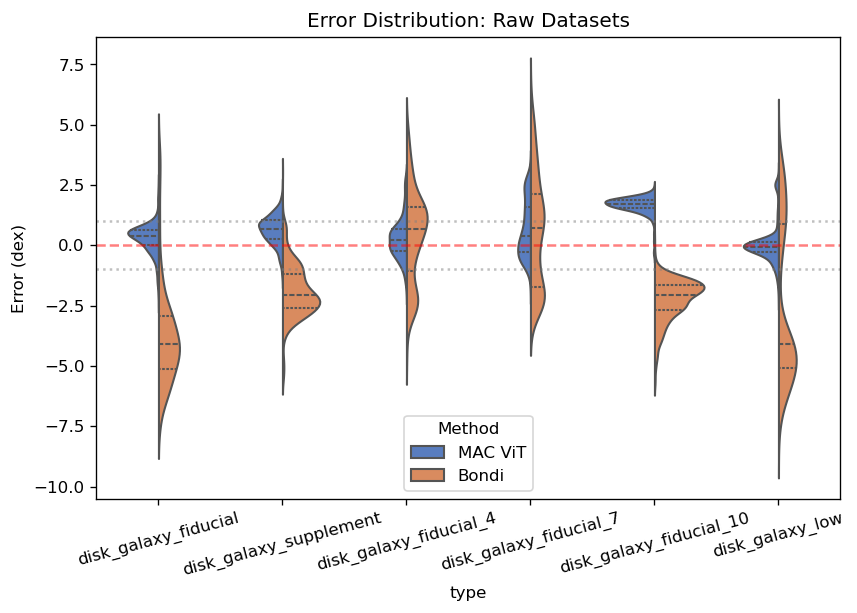

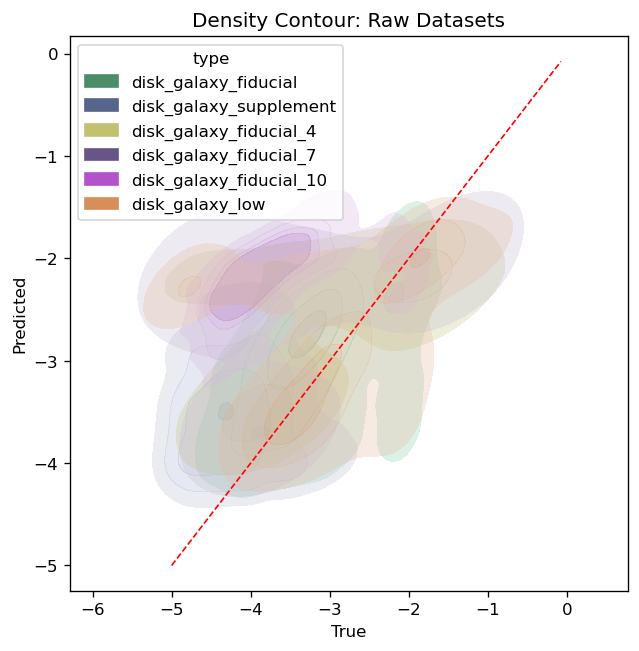

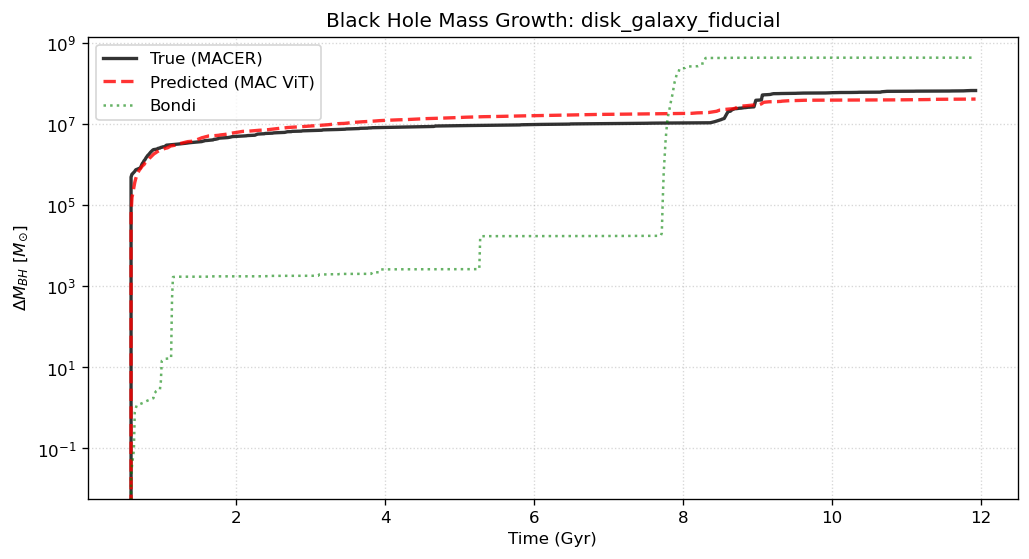

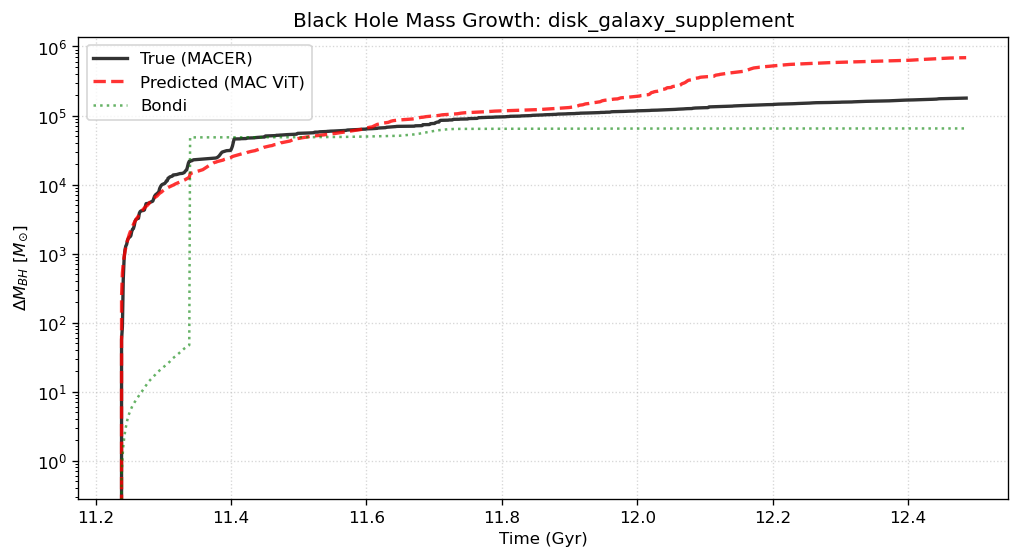

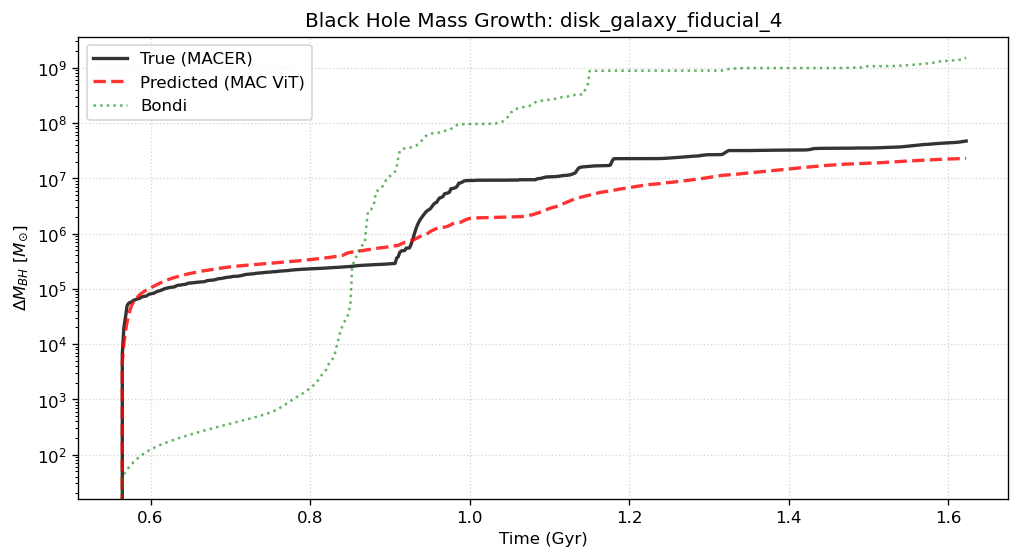

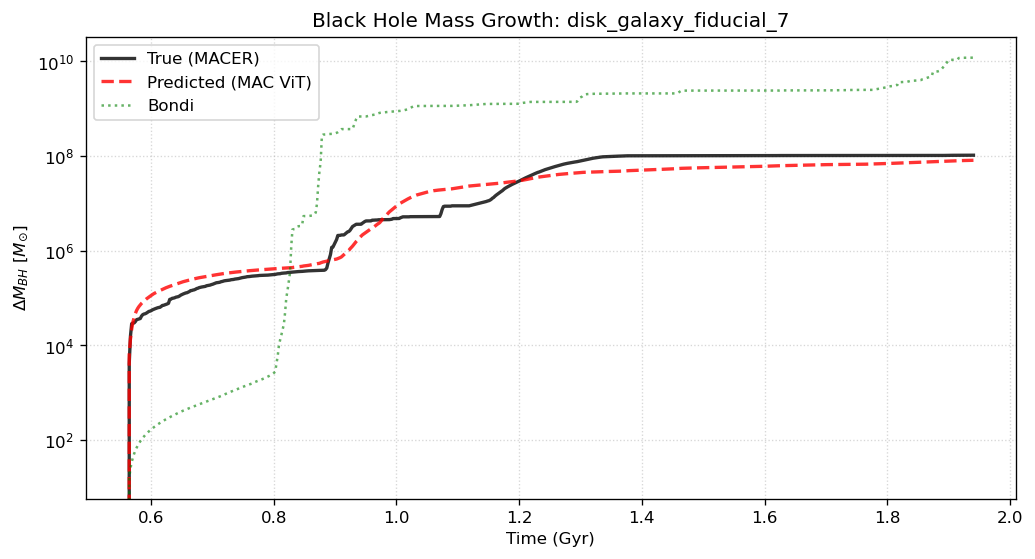

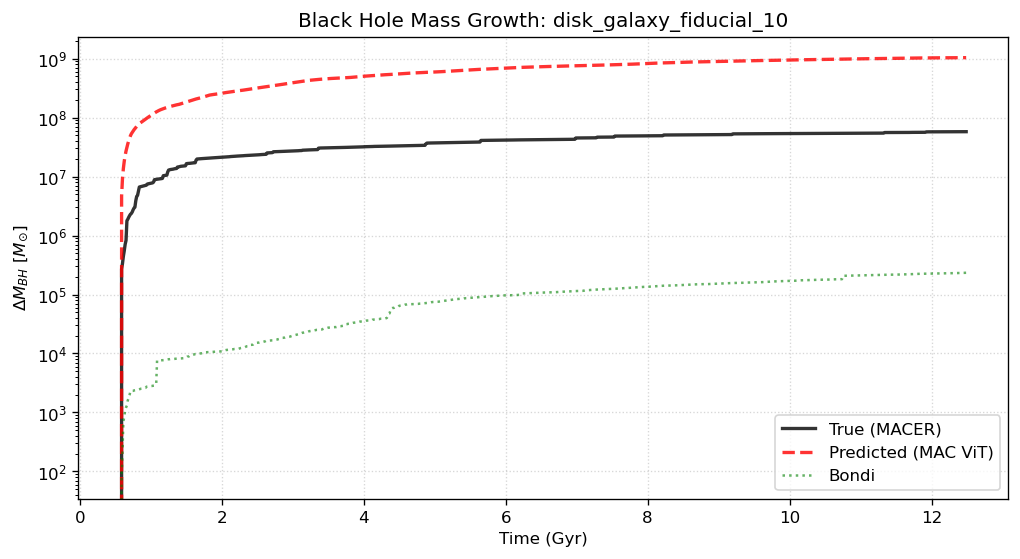

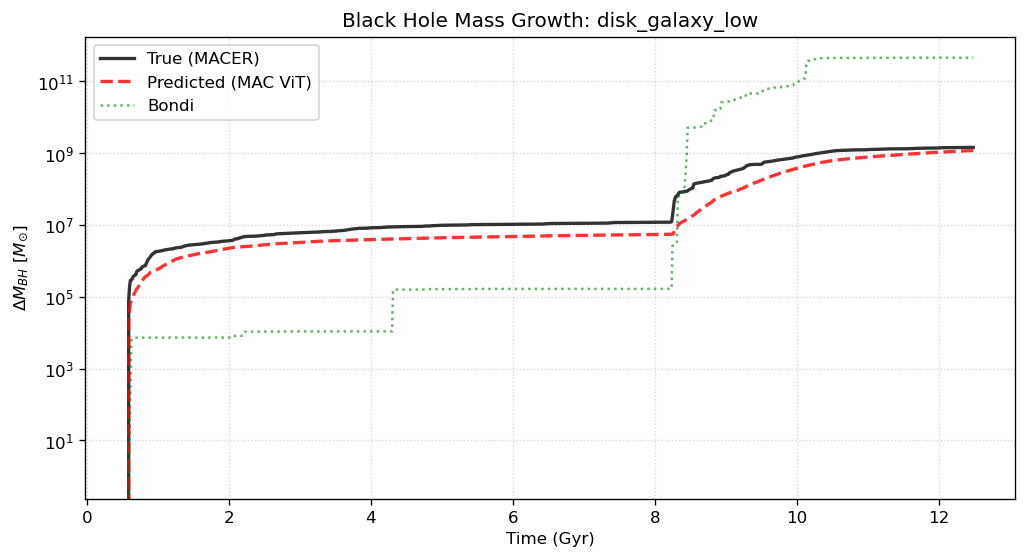


=== Statistical Summary ===


,Dataset,RMSE,MAE,R2,OutlierFrac (>1dex)
0,Cached Test (Model),0.828,0.595,0.090,14.601
1,Raw All (Model),1.114,0.868,-0.497,36.074
2,Raw All (Bondi),3.180,2.742,-11.197,87.185
3,Type: disk_galaxy_fiducial,0.680,0.553,-0.140,10.743
4,Type: disk_galaxy_supplement,0.882,0.753,-2.683,28.348
5,Type: disk_galaxy_fiducial_4,0.903,0.672,0.293,18.814
6,Type: disk_galaxy_fiducial_7,1.333,1.020,-0.198,38.330
7,Type: disk_galaxy_fiducial_10,1.704,1.668,-11.739,95.803
8,Type: disk_galaxy_low,0.804,0.477,0.175,14.225


C:\Users\Administrator\AppData\Local\Temp\ipykernel_34968\3227490209.py:124: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(df_plot['Dataset'], rotation=45, ha='right')
C:\Users\Administrator\AppData\Local\Temp\ipykernel_34968\3227490209.py:130: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[2].set_xticklabels(df_plot['Dataset'], rotation=45, ha='right')


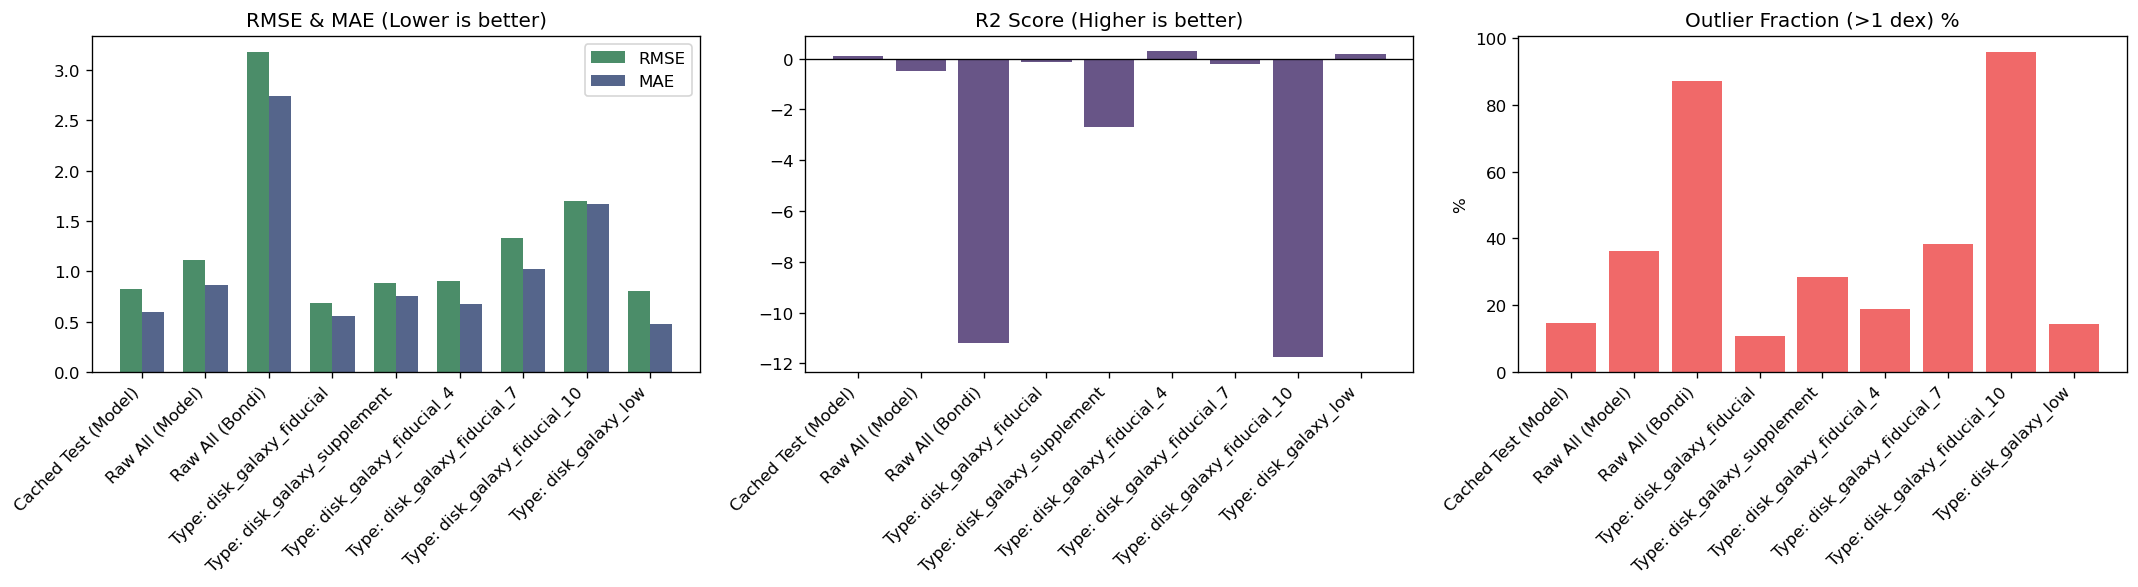

In [8]:
# ==========================================
# 8. Metrics & Final Execution
# ==========================================

def get_metrics(y_true, y_pred, name=""):
    d = y_true - y_pred
    return {
        'Dataset': name,
        'RMSE': np.sqrt(np.mean(d**2)),
        'MAE': np.mean(np.abs(d)),
        'R2': r2_score(y_true, y_pred),
        'OutlierFrac (>1dex)': np.mean(np.abs(d) > 1.0) * 100
    }

metrics_list = []

# Process Test Cache
if 'test_cached' in all_results:
    df_test = all_results['test_cached']
    metrics_list.append(get_metrics(df_test['y_true'], df_test[COL_PRED], "Cached Test (Model)"))
    plot_scatter(df_test, "Cached Test Set")

# Process Raw Data
if 'raw_all' in all_results:
    df_raw = all_results['raw_all']
    # Total
    metrics_list.append(get_metrics(df_raw['y_true'], df_raw[COL_PRED], "Raw All (Model)"))
    if 'y_bondi' in df_raw.columns:
         valid_b = df_raw.dropna(subset=['y_bondi'])
         metrics_list.append(get_metrics(valid_b['y_true'], valid_b['y_bondi'], "Raw All (Bondi)"))

    # Plotting
    plot_scatter(df_raw, "All Raw Datasets")
    plot_error_dist(df_raw, "Raw Datasets")
    plot_kde_contour(df_raw, "Raw Datasets")
    
    # Per Type Metrics & Mass Evolution
    for t in df_raw['type'].unique():
        sub = df_raw[df_raw['type'] == t]
        metrics_list.append(get_metrics(sub['y_true'], sub[COL_PRED], f"Type: {t}"))
        # New: Plot mass evolution for each simulation sequence
        plot_mass_evolution(sub, f"{t}")

# Display Metrics Table
metrics_df = pd.DataFrame(metrics_list)
# Format for better display
pd.options.display.float_format = '{:,.3f}'.format
print("\n=== Statistical Summary ===")
display(metrics_df)

# Visualizing Metrics Summary
plot_metrics_summary(metrics_df)

# Save Metrics
metrics_df.to_csv(output_dir / "summary_metrics.csv", index=False)

In [9]:
# ==========================================
# 9. Save Summary to Markdown
# ==========================================
import os

# Define the path for the markdown file in the output (exp*) folder
# output_dir is defined in cell 6 as model_path.parent
md_path = output_dir / "summary_metrics.md"

with open(md_path, 'w', encoding='utf-8') as f:
    f.write("# Analysis Results: " + EXP_PREFIX + "\n\n")
    
    f.write("## Model Information\n")
    f.write(f"- **Target Model**: `{model_path.relative_to(project_root)}`\n")
    f.write(f"- **Detected Architecture**: `{model_type.upper()}`\n\n")
    
    f.write("## Dataset Information\n")
    for split, ds in datasets.items():
        if ds is not None:
            f.write(f"- **{split.upper()}**: {len(ds)} samples ({ds.kind})\n")
    f.write("\n")
    
    f.write("## Statistical Summary\n\n")
    f.write("| " + " | ".join(metrics_df.columns) + " |\n")
    f.write("| " + " | ".join(["---"] * len(metrics_df.columns)) + " |\n")
    for _, row in metrics_df.iterrows():
        f.write("| " + " | ".join([f"{val:.3f}" if isinstance(val, (float, np.float32, np.float64)) else str(val) for val in row]) + " |\n")
    
    f.write("\n## Visualizations\n\n")
    if SAVE_FIGURES:
        f.write("### General Statistics\n\n")
        # List of plots we expect to see in the figures dir
        plots = [
            ("Metrics Summary", "metrics_summary"),
            ("Scatter: Cached Test Set", "scatter_cached_test_set"),
            ("Scatter: All Raw Datasets", "scatter_all_raw_datasets"),
            ("Error Distribution", "violin_raw_datasets"),
            ("Density Contour", "kde_raw_datasets")
        ]
        for label, fname in plots:
            img_path = f"{FIGURE_SUBDIR}/{fname}.{FIGURE_FORMAT}"
            f.write(f"#### {label}\n")
            f.write(f"![{label}]({img_path})\n\n")
            
        # New: Add Mass Evolution plots for each raw dataset type
        if 'raw_all' in all_results:
            f.write("### Black Hole Mass Evolution\n\n")
            for t in all_results['raw_all']['type'].unique():
                clean_t = t.replace(' ', '_').lower()
                fname = f"mass_evo_{clean_t}"
                img_path = f"{FIGURE_SUBDIR}/{fname}.{FIGURE_FORMAT}"
                f.write(f"#### Mass Growth: {t}\n")
                f.write(f"![{t}]({img_path})\n\n")
    
    f.write("\n## Output Directory\n")
    f.write(f"This file and all associated results are saved in: `{output_dir.relative_to(project_root)}`\n")

print(f"Analysis report successfully recorded in {md_path}")

Analysis report successfully recorded in D:\PersonFiles\Codes\Project\MACNet v1\Results\Exp_ViT_00120260116_145955\summary_metrics.md
